# Getting started: the NiSpace object

This notebook introduces the core NiSpace API through a complete, step-by-step colocalization analysis. If you haven't already, have a look at the [Spatial Colocalization notebook](intro1_spatial_colocalizations.ipynb) for the conceptual background.

We'll use a NeuroQuery meta-analytic map for "pain" as our input and test whether it colocalizes with a set of PET-derived neurotransmitter receptor maps. This is a clean, self-contained example with a nice biological story.

In [1]:
# make progress bars render as text in the docs
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

## The input map: a NeuroQuery pain map

We need a brain map to start with. I downloaded a meta-analytic map from [NeuroQuery](https://neuroquery.org/query?text=pain) — a tool that generates brain activation maps from text queries against the neuroimaging literature. The map for "pain" is a z-score image reflecting how consistently the pain literature reports activation across brain regions.

Technically this is not a T-map from a single study, but it serves our purpose perfectly: it's a plausible spatial pattern of pain-related brain activity, and it lives in MNI space like all our reference data.

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

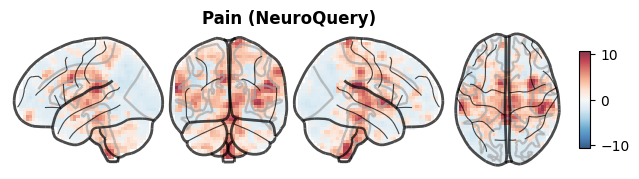

In [2]:
from nispace.io import load_img
from nispace.plotting import brainplot

# load the pain map
pain_map = load_img("neuroquery/pain.nii.gz")

# plot it
brainplot(pain_map, title="Pain (NeuroQuery)")

The map shows the expected pattern: activation in regions associated with pain processing, including the insula, anterior cingulate cortex, and somatosensory cortex.

## Reference data: PET receptor maps

For our reference maps, we'll use NiSpace's curated PET receptor dataset. This collection contains group-average receptor density maps for a wide range of neurotransmitter receptors and transporters, derived from PET studies in healthy subjects.

We fetch the data already parcellated into our target parcellation. This is much faster than loading the volumetric images and parcellating them on the fly — NiSpace ships pre-parcellated versions of all reference datasets.

In [3]:
from nispace.datasets import fetch_reference

# fetch the PET maps, pre-parcellated into Schaefer200
# collection="UniqueTracers" picks one representative tracer per receptor target
pet_maps = fetch_reference(
    "pet",
    parcellation="Schaefer200",
    collection="UniqueTracers",
    print_references=False  # suppress the long reference list for now
)

print(f"PET DataFrame: {pet_maps.shape[0]} maps x {pet_maps.shape[1]} parcels")
pet_maps.head(3)

INFO | 31/05/26 13:28:24 | nispace.datasets: Loading pet maps.


INFO | 31/05/26 13:28:24 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 31/05/26 13:28:24 | nispace.datasets: Filtering maps by collection.


INFO | 31/05/26 13:28:24 | nispace.datasets: Loading data parcellated with 'Schaefer200Parcels7Networks'


Updating /Users/llotter/nispace-data/reference/pet/tab/dset-pet_parc-Schaefer200Parcels7Networks.csv.gz
PET DataFrame: 29 maps x 200 parcels


hemi-L_div-Vis_lab-1  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.677147   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.602272   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.651551   

                                                            hemi-L_div-Vis_lab-2  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.666611   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.624987   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.606582   

                                                            hemi-L_div-Vis_lab-3  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.633823   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.600528   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.616104   

                                                            hemi-L_div-Vis_lab-4  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.712379   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.611747   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.570561   

                                                            hemi-L_div-Vis_lab-5  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.604150   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.642787   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.536395   

                                                            hemi-L_div-Vis_lab-6  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.590683   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.490786   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.509607   

                                                            hemi-L_div-Vis_lab-7  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.707724   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.707251   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.563901   

                                                            hemi-L_div-Vis_lab-8  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.684077   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.654593   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.675601   

                                                            hemi-L_div-Vis_lab-9  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.621863   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.710693   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.618253   

                                                            hemi-L_div-Vis_lab-10  \
set     map                                                                         
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...               0.791744   
        target-r

The DataFrame has a two-level index: the first level is the neurotransmitter system ("set"), the second is the full tracer identifier. These sets are used later for X-Set Enrichment Analysis ([XSEA notebook](intro10_xsea.ipynb)) — for now we just treat the whole thing as a collection of maps.

## Initializing the NiSpace object

NiSpace follows an object-oriented design. We first create a `NiSpace` instance, passing all the data and configuration options. Processing happens later when we call the analysis methods.

The two central arguments are:
- `x`: the reference maps (here: PET receptor maps)
- `y`: the input map(s) we want to analyze (here: the pain map)

We also specify the parcellation, which tells NiSpace how to parcellate `y` (since it's a volumetric NIfTI image) and how to align it with `x` (which is already a parcellated DataFrame).

In [4]:
from nispace.api import NiSpace

nsp = NiSpace(
    x=pet_maps,        # reference maps
    y=pain_map,        # input map — will be parcellated automatically
    y_labels="Pain",   # a name for our input map
    parcellation="Schaefer200",
    n_proc=4,          # use 4 parallel processes where possible
    seed=42            # for reproducibility
)

print(nsp)

## Fitting: parcellation and data ingestion

Calling `fit()` is where actual data processing begins. For the pain map (a NIfTI image), this means parcellating it into the 200 Schaefer regions. For the PET maps (already a DataFrame), it validates and stores the data.

In [5]:
nsp.fit()

# inspect the parcellated pain map
print("Parcellated pain map:")
nsp.get_y()

INFO | 31/05/26 13:28:24 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 31/05/26 13:28:24 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200Parcels7Networks' from library.


INFO | 31/05/26 13:28:24 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR


INFO | 31/05/26 13:28:24 | nispace.core.parcellation:   No pre-computed spin matrix for 'Schaefer200Parcels7Networks' in 'fsaverage'.


INFO | 31/05/26 13:28:24 | nispace.core.parcellation:   No pre-computed spin matrix for 'Schaefer200Parcels7Networks' in 'fsLR'.


...

Parcellating (4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 131.84it/s]

INFO | 31/05/26 13:28:28 | nispace.api: Got 'y' data for 1 x 200 parcels.


INFO | 31/05/26 13:28:28 | nispace.api: Z-standardizing 'X' data.


Parcellated pain map:
INFO | 31/05/26 13:28:28 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


,hemi-L_div-Vis_lab-1,hemi-L_div-Vis_lab-2,hemi-L_div-Vis_lab-3,hemi-L_div-Vis_lab-4,hemi-L_div-Vis_lab-5,hemi-L_div-Vis_lab-6,hemi-L_div-Vis_lab-7,hemi-L_div-Vis_lab-8,hemi-L_div-Vis_lab-9,hemi-L_div-Vis_lab-10,...,hemi-R_div-Default_lab-PFCm+1,hemi-R_div-Default_lab-PFCm+2,hemi-R_div-Default_lab-PFCm+3,hemi-R_div-Default_lab-PFCm+4,hemi-R_div-Default_lab-PFCm+5,hemi-R_div-Default_lab-PFCm+6,hemi-R_div-Default_lab-PFCm+7,hemi-R_div-Default_lab-PCC+1,hemi-R_div-Default_lab-PCC+2,hemi-R_div-Default_lab-PCC+3
Pain,-0.436623,-1.075635,-0.893094,-0.887707,-1.139506,-1.259002,-1.339256,-1.083586,-1.389717,-0.828569,...,-0.463824,-0.154211,0.643321,-0.584073,-0.205924,0.174392,0.172215,-0.319737,-0.818837,-0.344202


The parcellated data is stored internally. `get_y()` returns the input maps, `get_x()` returns the reference maps — both as DataFrames with maps in rows and parcels in columns.

## Colocalization

Now for the core step: computing correlations between the pain map and each PET receptor map. We use Spearman rank correlation, which is robust to outliers and doesn't assume normally distributed data.

In [6]:
nsp.colocalize("spearman")

# get the results
colocs = nsp.get_colocalizations()
print(f"Results: {colocs.shape[0]} input maps x {colocs.shape[1]} reference maps")

# show sorted by colocalization value
colocs.T.sort_values(by="Pain", ascending=False)

INFO | 31/05/26 13:28:28 | nispace.api: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***


INFO | 31/05/26 13:28:28 | nispace.api: Running 'spearman' colocalization.


INFO | 31/05/26 13:28:28 | nispace.api: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc):   0%|                                                                                                                                                                                             | 0/1 [00:00<?, ?it/s]

Colocalizing (spearman, 4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1757.88it/s]

INFO | 31/05/26 13:28:31 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


Results: 1 input maps x 29 reference maps


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.435971
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.339014
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.309315
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.304823
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.219451
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.176491
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.151909
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,0.129229
GABA,target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022,0.111743


The result is a DataFrame with one row per input map (here: "Pain") and one column per reference map. The values are Spearman ρ.

We can see which receptors show the strongest positive and negative colocalizations. But these bare correlation values don't come with reliable p-values yet — we haven't accounted for spatial autocorrelation. That's where permutation testing comes in.

## Permutation testing

We call `permute()` with `"maps"` to generate spatially-constrained null versions of the PET maps and recompute correlations 10,000 times. This gives us an empirical null distribution for each receptor.

We pass `p_tails="upper"` because our hypothesis is directional: we expect *positive* colocalizations with receptors involved in pain processing (opioids, noradrenergic/cholinergic pathways).

Null model details are covered in the [Null Models notebook](intro5_null_models.ipynb). For now, just note that by default NiSpace uses spin-based surrogate maps if possible (Alexander-Bloch method), which preserve the spatial autocorrelation of the original data.

In [7]:
nsp.permute(
    "maps",
    n_perm=10000,
    p_tails="upper",  # one-tailed: test for positive colocalization, default is "two"
)

# multiple comparison correction across the 29 receptor maps
nsp.correct_p(mc_method="fdr_bh")

p_values = nsp.get_p_values()

# show p-values sorted ascending
p_values.T.sort_values(by="Pain")

INFO | 31/05/26 13:28:31 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***


INFO | 31/05/26 13:28:31 | nispace.api: Permutation of: X maps.


INFO | 31/05/26 13:28:31 | nispace.api: Using default null method 'alexander_bloch' (parcellation null space: 'fsLR').


INFO | 31/05/26 13:28:31 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 31/05/26 13:28:31 | nispace.api: Loading observed colocalizations (method = 'spearman').


...

INFO | 31/05/26 13:28:49 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


INFO | 31/05/26 13:28:49 | nispace.api: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***


INFO | 31/05/26 13:28:49 | nispace.api: Correction method: 'fdr_bh', alpha: 0.05, dimension: 'array'.


INFO | 31/05/26 13:28:49 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.0101
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.0202
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.0503
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.0776
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.1693
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.2317
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.2604
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,0.2714
GABA,target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022,0.3376


After correcting for spatial autocorrelation (via permutation) and for multiple comparisons across the 29 receptor maps (FDR), the cholinergic transporter VAChT stands out with the lowest p-value — consistent with the pain neuroscience literature.

Notice that the effect sizes haven't changed: permutation testing and `correct_p()` only affect the p-values, not the correlations.

## Visualizing the results

NiSpace has an integrated `plot()` method that picks a reasonable visualization automatically. Pass `mc_method="fdr_bh"` to show significance markers based on the corrected p-values.

INFO | 31/05/26 13:28:49 | nispace.api: *** NiSpace.plot() - Plot colocalization results. ***


INFO | 31/05/26 13:28:49 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 31/05/26 13:28:50 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 31/05/26 13:28:50 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 31/05/26 13:28:50 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | fdrbh     | False       | False       | 


INFO | 31/05/26 13:28:50 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 31/05/26 13:28:50 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_fdr_bh < 0.05


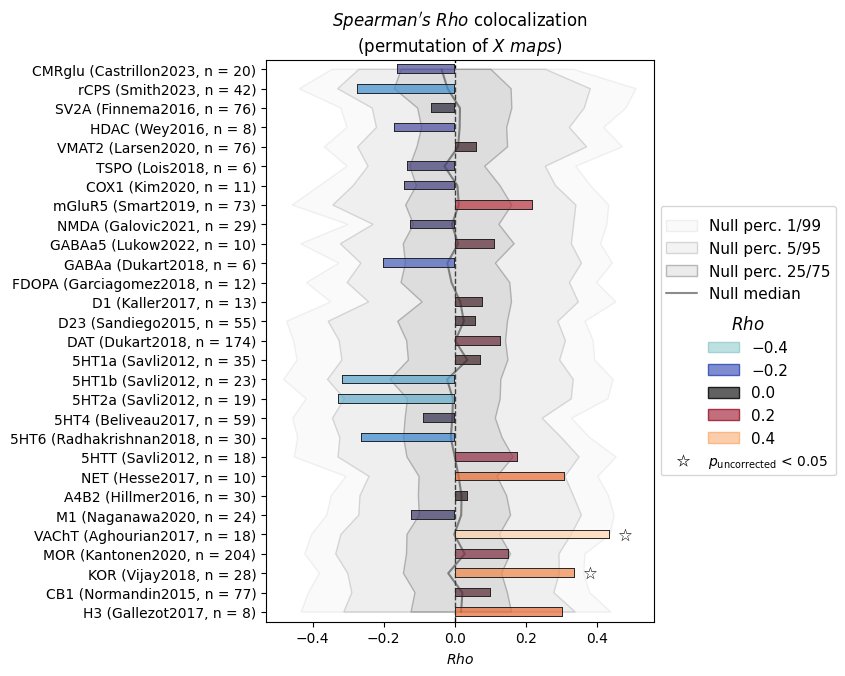

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x312e0e430>)

In [8]:
nsp.plot(mc_method="fdr_bh")

We can also visualize the input and reference maps as above, but here directly from NiSpace object:

INFO | 31/05/26 13:28:51 | nispace.api: *** NiSpace.plot_brain() ***


INFO | 31/05/26 13:28:51 | nispace.api: Plotting Y data (Y_transform='False').


INFO | 31/05/26 13:28:51 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


WARNING | 31/05/26 13:28:51 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 31/05/26 13:28:51 | nispace.plotting: brainplot: threshold='auto' → 0.005351351574063301


INFO | 31/05/26 13:28:51 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


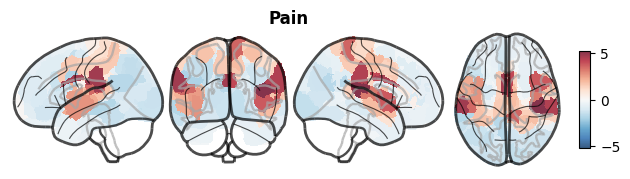

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [9]:
# the pain map
nsp.plot_brain(data="Y")

INFO | 31/05/26 13:28:54 | nispace.api: *** NiSpace.plot_brain() ***


INFO | 31/05/26 13:28:54 | nispace.api: Plotting X data (X_reduction='False').


INFO | 31/05/26 13:28:54 | nispace.api: Returning X dataframe: 
| X_REDUCTION | 
| False       | 


WARNING | 31/05/26 13:28:54 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 31/05/26 13:28:54 | nispace.plotting: brainplot: threshold='auto' → 0.019260043278336525


INFO | 31/05/26 13:28:54 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


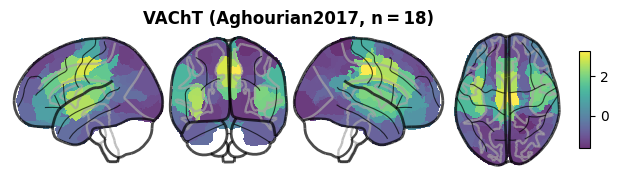

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [10]:
# the VAChT receptor map (strongest colocalization)
nsp.plot_brain(data="X", maps="VAChT", symmetric_cmap=False)

## Saving and loading

Analyses with 10,000 permutations take time. We can serialize the entire NiSpace object — including the null distributions — to disk with `to_pickle()`, and load it back with `from_pickle()`.

We recommend the `.pkl.blosc` format: Blosc compression keeps file sizes manageable without the speed penalty of gzip.

In [11]:
import os

# save, including the null distributions
nsp.to_pickle("nsp_pain.pkl.blosc")
print(f"With nulls:    {os.path.getsize('nsp_pain.pkl.blosc') / 1e6:.1f} MB")

# save without nulls — much smaller, but you lose the shading in plots
nsp.to_pickle("nsp_pain_no_nulls.pkl.blosc", save_nulls=False)
print(f"Without nulls: {os.path.getsize('nsp_pain_no_nulls.pkl.blosc') / 1e6:.1f} MB")

With nulls:    224.1 MB
Without nulls: 5.3 MB


In [12]:
# load it back
nsp_loaded = NiSpace.from_pickle("nsp_pain.pkl.blosc")

import numpy as np
assert np.allclose(
    nsp.get_colocalizations().values,
    nsp_loaded.get_colocalizations().values
)
print("Loaded successfully — results are identical.")

INFO | 31/05/26 13:28:59 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 31/05/26 13:28:59 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


Loaded successfully — results are identical.


## Summary

The complete NiSpace workflow in six lines:

```python
nsp = NiSpace(x=reference_maps, y=input_map, parcellation="Schaefer200")
nsp.fit()                                          # parcellate + ingest
nsp.colocalize("spearman")                         # compute correlations
nsp.permute("maps", n_perm=10000, p_tails="upper") # permutation p-values
nsp.correct_p(mc_method="fdr_bh")                 # multiple comparisons correction
nsp.plot(mc_method="fdr_bh")                       # visualize
```

The next notebook covers [what datasets and parcellations are available, and how to bring in your own data](intro3_fetching_datasets.ipynb).